# Random Forest Methodology

Random forest is an ensemble learning method for classification and regression that constructs a multitude of decision trees during training and outputs the mode of the classes or the mean prediction of the individual trees. The method is grounded in the principles of bootstrap aggregation and randomized feature selection, which together reduce variance and improve generalization relative to a single decision tree.

## Fundamental Principles

1. Bootstrap aggregation (bagging)

- Given a training dataset $ \mathcal{D} = \{(x_i, y_i)\}_{i=1}^N $, a random forest generates $ M $ bootstrap samples $ \mathcal{D}_m $, each obtained by sampling $ N $ examples from $ \mathcal{D} $ with replacement.
- Each bootstrap sample is used to train a decision tree $ T_m $.
- The aggregation of trees mitigates overfitting by averaging multiple uncorrelated or weakly correlated predictors.

2. Random feature selection

- At each split in a tree, only a subset of features of size $ k $ is considered, where typically $ k = \sqrt{p} $ for classification and $ k = p/3 $ for regression, with $ p $ the total number of predictors.
- This randomization reduces the correlation between individual trees and increases ensemble diversity.

## Tree Construction

A single tree in a random forest is grown as follows:

- Recursive partitioning: the feature space is partitioned by binary splits.
- At each internal node, choose a feature subset $ \mathcal{F} \subseteq \{1, \dots, p\} $ of cardinality $ k $.
- For each feature $ j \in \mathcal{F} $, select the split point $ s $ that optimizes an impurity criterion.

For classification, common impurity measures are:

- Gini impurity:
$$
G(t) = \sum_{c=1}^C p_{c}(t)\bigl(1 - p_{c}(t)\bigr)
$$

- Entropy:
$$
H(t) = - \sum_{c=1}^C p_{c}(t) \log p_{c}(t)
$$

where $ p_{c}(t) $ is the proportion of class $ c $ in node $ t $.

For regression, the typical criterion is mean squared error:
$$
\text{MSE}(t) = \frac{1}{N_t} \sum_{i \in t} (y_i - \bar{y}_t)^2
$$
where $ \bar{y}_t $ is the mean response in node $ t $.

A tree is grown to maximum depth or until terminal nodes contain a minimum number of samples. Importantly, trees in a random forest are not pruned.

## Ensemble Prediction

Given $ M $ trees $ \{T_1, \dots, T_M\} $:

- Classification prediction:
$$
\hat{y} = \arg\max_{c} \sum_{m=1}^M \mathbf{1}\{T_m(x) = c\}
$$

- Regression prediction:
$$
\hat{y} = \frac{1}{M} \sum_{m=1}^M T_m(x)
$$

The ensemble prediction is thus an aggregation of independent learners, which stabilizes estimates and reduces variance.

## Theoretical Motivation

The error of an ensemble can be decomposed in terms of bias and variance. Random forests aim to preserve the low bias of deep decision trees while significantly reducing variance through averaging. If $ \rho $ denotes the mean correlation between tree predictions and $ s^2 $ their variance, the variance of the ensemble is approximately:
$$
\text{Var}(\hat{y}) \approx \rho s^2 + \frac{1-\rho}{M} s^2
$$
A smaller $ \rho $ amplifies the benefit of averaging.

## Practical Considerations

- Number of trees $ M $: large enough to stabilize out-of-bag error; additional trees do not degrade performance.
- Number of features $ k $: controls the strength-correlation tradeoff. Smaller $ k $ increases diversity but may reduce individual tree accuracy.
- Minimum node size and maximum depth: influence tree complexity and overfitting.

## Out-of-Bag Estimation

For each observation, trees trained without that observation form an out-of-bag (OOB) ensemble. The OOB estimate approximates the generalization error without requiring a separate validation set.

- OOB prediction for sample $ i $:
$$
\hat{y}_i^{\text{OOB}} = \frac{1}{|\mathcal{M}_i|} \sum_{m \in \mathcal{M}_i} T_m(x_i)
$$
where $ \mathcal{M}_i $ is the set of trees not trained on $ i $.

## Variable Importance

Random forests provide measures of variable importance, such as:

- Mean decrease in impurity
- Permutation importance: the increase in error when a variable is randomly permuted in the OOB samples.

These measures help interpret model structure and identify predictive features.

## Summary

Random forests combine bootstrap aggregation and randomized split selection to create a robust ensemble of decision trees. The method is characterized by:

- High predictive performance
- Resistance to overfitting
- Built-in estimates of generalization error
- Measures of feature importance

Its methodological strength lies in balancing the low bias of deep decision trees with the reduced variance obtained from an ensemble of de-correlated learners.

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

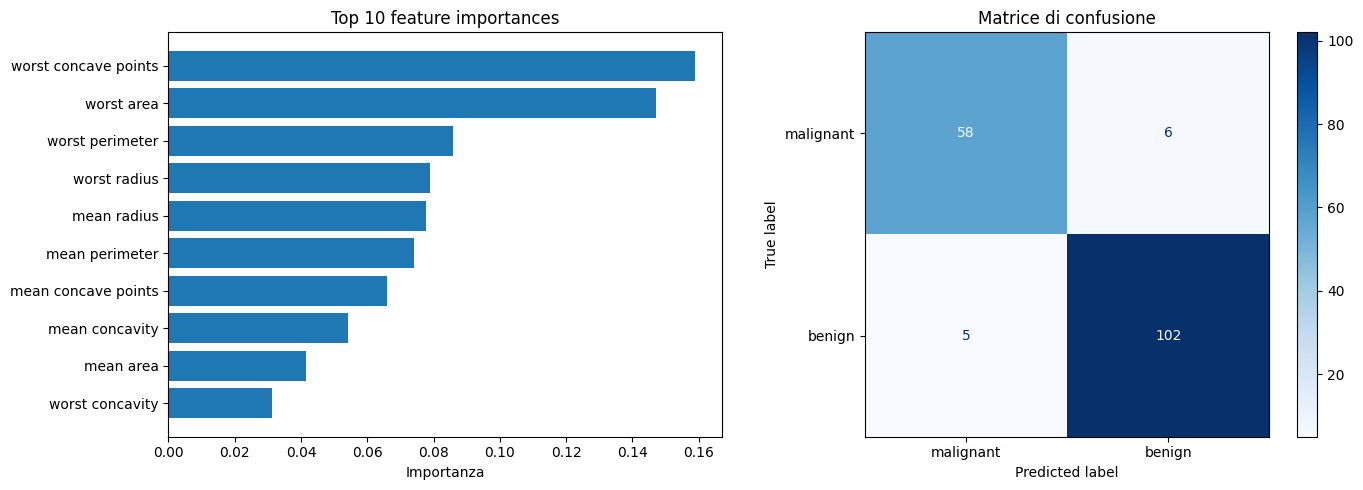

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Carico un dataset reale disponibile in sklearn
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# Mostro le prime righe
df = X.copy()
df["target"] = y
print(df.head())

# Suddivisione train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Addestramento del modello Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Valutazione
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot feature importance e matrice di confusione
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-10:]
ax[0].barh(np.array(X.columns)[top_idx], importances[top_idx])
ax[0].set_title("Top 10 feature importances")
ax[0].set_xlabel("Importanza")

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(ax=ax[1], cmap="Blues")
ax[1].set_title("Matrice di confusione")

plt.tight_layout()
plt.show()